# Indicator vs Monthly Return Testing

This notebook loads a JSON file containing indicator values and a monthly return variable, then automatically generates scatter plots of each indicator vs the monthly return.

In [3]:
import itertools
import json
import matplotlib.pyplot as plt
import numpy as np 
import os
import pandas as pd 
import warnings
from pathlib import Path
from sklearn.model_selection import train_test_split, cross_validate
from sklearn.metrics import mean_squared_error, mean_absolute_error, mean_absolute_percentage_error, r2_score
from sklearn.model_selection import cross_val_score
# For ARIMA model
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX
# For ADF test (Augmented Dickey-Fuller)
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.stattools import kpss
# For ACF and PACF plots
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

In [4]:
# Suppress warnings to keep your notebook output clean
warnings.filterwarnings("ignore")

# Ensure matplotlib plots render inline in the notebook
%matplotlib inline

In [5]:

print(os.getcwd())


c:\Users\20231351\Documents\HTT\Time Series Project


In [6]:
Path.cwd().parent

WindowsPath('c:/Users/20231351/Documents/HTT')

In [7]:
path = Path.cwd().parent / "Time Series Project" / "oil_industry_data.json"
jdf = pd.read_json(path)
jdf

,XOM,CVX,SHEL,TTE,PBR,PBR.A,BP,EQNR,E,SU,...,CRT,PVL,PRT,USEG,MXC,CKX,EONR,BRN,MTR,TPET
2025-12-31,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,None,NaN,NaN,NaN,NaN,NaN
2025-09-30,NaN,"{'BOED': 6609000, 'OCF/BOED': 3502.79921319412...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,None,"{'BOED': 1000000, 'OCF/BOED': 0.336296, 'ROA':...",NaN,NaN,NaN,NaN
2025-06-30,NaN,"{'BOED': 3346500, 'OCF/BOED': 4113.25265202450...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,None,"{'BOED': 150000, 'OCF/BOED': 0.626840000000000...",NaN,NaN,NaN,NaN
2024-12-31,NaN,"{'BOED': 3338000, 'OCF/BOED': 9434.39185140802...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,"{'BOED': 225.33, 'OCF/BOED': 13052.47858696134...","{'BOED': 22061.19, 'OCF/BOED': 9.2815029470305...",NaN,NaN,NaN,NaN
2025-03-31,NaN,"{'BOED': 13412000, 'OCF/BOED': 386.89233522218...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,None,"{'BOED': 100000, 'OCF/BOED': 1.186640000000000...",NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1996-09-30,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,None,None,NaN,NaN,NaN,NaN
1996-06-30,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,None,None,NaN,NaN,NaN,NaN
1996-03-31,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,None,None,NaN,NaN,NaN,NaN
1995-12-31,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,None,None,NaN,NaN,NaN,NaN


In [8]:
s = jdf.stack()
s = s[s.map(type).eq(dict)]

out = pd.json_normalize(s.values)
out.index = s.index
out = out.reset_index()
out.columns = ['Date', 'Ticker'] + list(out.columns[2:])
out = out.drop(columns='Date')
out

,Ticker,BOED,OCF/BOED,ROA,CostExpenses/BOED,Stock/Oil ZScore,PGR,Monthly Return
0,NFG,53051.0,5182.202032,1.973143,7075.908088,2.825966,11.730000,8.880840
1,COP,224000.0,88375.000000,6.550816,29205.357143,1.994985,21.739130,16.205524
2,FANG,497156.0,17616.200951,2.341716,27677.429217,2.364790,53.530000,12.146607
3,DVN,389000.0,17251.928021,8.361024,7275.064267,1.153904,-0.410000,20.229319
4,EXE,16164.0,283036.377134,6.430516,597191.289285,2.376671,90.672727,-6.895615
...,...,...,...,...,...,...,...,...
765,CKX,100000.0,4.419620,8.743000,2.191770,-0.371745,0.000000,-4.316563
766,CKX,21176000.0,0.020871,8.743000,0.010350,-0.371745,829.587357,-4.316563
767,MXC,104401.0,11.141186,0.976244,29.401519,-0.713093,0.000000,1.960771
768,CKX,17610000.0,0.025097,8.743000,0.012446,-0.371745,674.070000,-4.316563


In [9]:
# Make sure oil_industry_data.json is in the same level as this notebook
with open('oil_industry_data.json') as f:
    oil_industry_data =  json.load(f)

oil_industry_data

{'XOM': {'2025-12-31': None,
  '2025-09-30': None,
  '2025-06-30': None,
  '2024-12-31': None,
  '2025-03-31': None,
  '2024-09-30': None,
  '2024-06-30': None,
  '2023-12-31': None,
  '2024-03-31': None,
  '2023-09-30': None,
  '2023-06-30': None,
  '2022-12-31': None,
  '2023-03-31': None,
  '2022-09-30': None,
  '2022-06-30': None,
  '2021-12-31': None,
  '2022-03-31': None,
  '2020-12-31': None,
  '2020-09-30': None,
  '2020-06-30': None,
  '2019-12-31': None,
  '2020-03-31': None,
  '2019-09-30': None,
  '2019-06-30': None},
 'CVX': {'2025-09-30': {'BOED': 6609000,
   'OCF/BOED': 3502.799213194129,
   'ROA': 1.0839170477272657,
   'CostExpenses/BOED': 6704.796489635346,
   'Stock/Oil ZScore': 1.8907107808119483,
   'PGR': 7.22,
   'Monthly Return': -1.2685841273981846},
  '2025-06-30': {'BOED': 3346500,
   'OCF/BOED': 4113.252652024503,
   'ROA': 0.9927438003349015,
   'CostExpenses/BOED': 12154.489765426564,
   'Stock/Oil ZScore': 1.2948218978736037,
   'PGR': 1.66,
   'Monthly R

## ARIMA Models

Basic Arima (not used)

In [10]:
def ARIMA_Stock_Analysis(ticker):
    # ==========================================
    # 1. Load Data & Extract Ticker 
    # ==========================================
    # Using the exact absolute path you provided
    oil_stock_data = oil_industry_data.get(ticker, {})
    records = []

    # Parse dates and Monthly Return, skipping nulls
    for date_str, metrics in oil_stock_data.items():
        if metrics is not None and "Monthly Return" in metrics:
            records.append({
                "Date": pd.to_datetime(date_str),
                "Monthly Return": metrics["Monthly Return"]
            })

    if not records:
        raise ValueError(f"No valid data found for {ticker}.")

    # Create DataFrame, set Date as index, sort chronologically
    df = pd.DataFrame(records).set_index("Date").sort_index()

    # Resample to Quarterly frequency to ensure an even time-series
    df = df.resample('Q').mean().interpolate()
    ts_data = df["Monthly Return"]

    print(f"Successfully loaded {len(ts_data)} valid quarterly data points for {ticker}.")

    # ==========================================
    # 2. Stationarity Check (ADF Test)
    # ==========================================
    print("\n--- Step 1: Stationarity Check (ADF Test) ---")
    adf_result = adfuller(ts_data)
    print(f"ADF Statistic: {adf_result[0]:.4f}")
    print(f"p-value: {adf_result[1]:.4f}")

    # Determine differencing parameter (d)
    d_val = 0 if adf_result[1] < 0.05 else 1
    print(f"-> Based on p-value, setting ARIMA differencing parameter (d) to: {d_val}")

    # ==========================================
    # 3. Autocorrelation Plots (ACF & PACF)
    # ==========================================
    print("\n--- Step 2: ACF & PACF Plots ---")
    fig, axes = plt.subplots(1, 2, figsize=(14, 4))
    plot_acf(ts_data, ax=axes[0], title="Autocorrelation (ACF) -> Determines 'q'")
    plot_pacf(ts_data, ax=axes[1], title="Partial Autocorr (PACF) -> Determines 'p'")
    plt.tight_layout()
    plt.show() 

    # ==========================================
    # 4. Fit the ARIMA Model
    # ==========================================
    print("\n--- Step 3: Fitting ARIMA Model ---")
    p, q = 1, 1 
    model = ARIMA(ts_data, order=(p, d_val, q))
    fitted_model = model.fit()

    print(fitted_model.summary())

    # ==========================================
    # 5. Forecasting & Visualization (3 YEARS AHEAD)
    # ==========================================
    print("\n--- Step 4: Forecasting ---")
    # Forecast the next 12 periods (3 Years, since data is quarterly)
    forecast_steps = 12
    forecast = fitted_model.get_forecast(steps=forecast_steps)
    forecast_mean = forecast.predicted_mean
    conf_int = forecast.conf_int()

    plt.figure(figsize=(12, 6))
    plt.plot(ts_data.index, ts_data, label="Historical CVX Monthly Returns", color="#1f77b4", marker="o")
    plt.plot(ts_data.index, fitted_model.fittedvalues, label="Model Fitted Values", color="green", linestyle="-")
    plt.plot(forecast_mean.index, forecast_mean, label="Forecast (Next 3 Years / 12 Quarters)", color="#d62728", linestyle="--", marker="x")

    plt.fill_between(conf_int.index, 
                    conf_int.iloc[:, 0], 
                    conf_int.iloc[:, 1], 
                    color="#d62728", alpha=0.15, label="95% Confidence Interval")

    plt.title(f"{ticker} Monthly Return - ARIMA Model Forecast (3-Year Horizon)", fontsize=14)
    plt.xlabel("Date", fontsize=12)
    plt.ylabel("Monthly Return (%)", fontsize=12)
    plt.axhline(0, color="black", linewidth=1, linestyle="--")
    plt.legend(loc="upper left")
    plt.grid(True, alpha=0.3)
    plt.show()

Filtering Data to Determine which stock datasets are viable for training

In [11]:
def load_data_for_ticker(ticker):
    try:
        # Load Data & Extract Ticker data
        oil_stock_data = oil_industry_data.get(ticker, {})

        # Convert the nested dictionary directly into a Pandas DataFrame
        df = pd.DataFrame.from_dict(oil_stock_data, orient='index')
        df.index = pd.to_datetime(df.index)

        # Sort chronologically and resample to Quarterly
        df = df.sort_index().resample('Q').mean()

        # Drop any columns that are 100% empty, then interpolate missing values
        df = df.dropna(axis=1, how='all')
        df = df.interpolate(method='linear', limit_direction='both')
        return df
    except:
        return None

In [12]:
def enough_data_points(ticker_data):
    if ticker_data is None:
        return False
    else:
        if len(ticker_data) < 20:
            return False
        else:
            return True

In [13]:
def check_stationary_category(column_data):
    adf_result = adfuller(column_data)
    kpss_result = kpss(column_data)

    if (adf_result[1] < 0.05 and kpss_result[1] > 0.05):
        # Stationary
        return "stationary"
    elif (adf_result[1] > 0.05 and kpss_result[1] < 0.05):
        # Unit-Root
        return "unit-root"
    else:
        # Neither
        return "other"

In [14]:
def check_arima_category(ticker_data):
    columns = ["OCF/BOED", "ROA", "CostExpenses/BOED", "Stock/Oil ZScore", "PGR"]

    arima_category = {'stationary': 0, 'unit_root': 0, 'other': 0}
    for indicator in columns:
        arima_type = check_stationary_category(ticker_data[indicator])
        if arima_type == "stationary":
            arima_category['stationary'] += 1
        elif arima_type == "unit-root": 
            arima_category['unit_root'] += 1
        else:
            arima_category['other'] +=1

    return max(arima_category, key=arima_category.get)

In [15]:
unviable = []
unit_root = []
stationary = []
other = []

# Filter stock data for following criteria:
# Atleast 5 years worth of quarterly data, monthly return is stationary
for stock_ticker in oil_industry_data.keys():
    ticker_data = load_data_for_ticker(stock_ticker)
    if not enough_data_points(ticker_data):
        unviable.append(stock_ticker)
    else:
        if len(ticker_data.columns) == 0:
            unviable.append(stock_ticker)
            continue

        if check_stationary_category(ticker_data["Monthly Return"]) == "stationary":
            arima_category = check_arima_category(ticker_data)

            if arima_category == "stationary":
                stationary.append(stock_ticker)
            elif arima_category == "unit_root":
                unit_root.append(stock_ticker)
            else:
                other.append(stock_ticker)
        else:
            unviable.append(stock_ticker)

In [16]:
stationary

['CVX', 'NFG', 'DVN', 'EXE', 'MTDR', 'CNX', 'NOG']

In [17]:
unit_root

['RRC', 'TALO']

SARIMAX Model Training

In [18]:
p = range(0, 5)
q = range(0, 5)
trainingset_stationary = {}

In [19]:
def test_model(y_train, X_train, order):
    model = SARIMAX(
        y_train,
        exog=X_train,
        order=order,
        enforce_stationarity=False,
        enforce_invertibility=False
    )
    
    results = model.fit(disp=False)
    return results

In [20]:
def create_trainingset(ticker_data):
    target_col = "Monthly Return"
    y = ticker_data[target_col]
    X = ticker_data.drop(columns=[target_col, "BOED"]) if "BOED" in ticker_data.columns else ticker_data.drop(columns=[target_col])
    X_lagged = X.shift(1)
    aligned_df = pd.concat([y, X_lagged], axis=1).dropna()
    y_aligned = aligned_df[target_col]
    X_lagged_aligned = aligned_df.drop(columns=[target_col])

    X_blocks = np.array_split(X_lagged_aligned, 3)
    y_blocks = np.array_split(y_aligned, 3)

    test_size = 4
    results = [] 

    # Keep track of accumulated training data
    accumulated_X_train = pd.DataFrame()
    accumulated_y_train = pd.Series(dtype=float)

    for block_id, block in enumerate(X_blocks):
        X_block_train = block.iloc[:-test_size]
        X_block_test = block.iloc[-test_size:]

        y_block_train = y_blocks[block_id].iloc[:-test_size]
        y_block_test = y_blocks[block_id].iloc[-test_size:]

        # ADD previous blocks' training data to current training set
        if block_id > 0:
            # Append previous training data to current
            X_block_train = pd.concat([accumulated_X_train, X_block_train])
            y_block_train = pd.concat([accumulated_y_train, y_block_train])

        block_dict = {'X_train': X_block_train, 'X_test': X_block_test, 'y_train': y_block_train, 'y_test': y_block_test}
        results.append(block_dict)

        # Update accumulated data with CURRENT block's training data
        # (This will be used as "previous" for the next block)
        accumulated_X_train = X_block_train
        accumulated_y_train = y_block_train
    
    return {'blocks': results, 'last_known_financials': X_lagged_aligned.iloc[-1:], 'y_aligned': y_aligned, 'X_lagged_aligned': X_lagged_aligned}

In [21]:
def calculate_expected_return(results, y_test, X_test):
    preds = results.get_forecast(steps=len(y_test), exog=X_test).predicted_mean
    returns = []

    # Start with net 0 return.
    for i, pred_value in enumerate(preds):
        if pred_value > 0:
            returns.append(y_test[i] / 100)
        else:
            returns.append(-y_test[i] / 100)
    
    returns_std = np.std(returns) if len(returns) > 0 else 0
    returns_mean = np.mean(returns) if len(returns) > 0 else 0
    
    sharpe_ratio = returns_mean / returns_std if returns_std > 0 else 0
    return sharpe_ratio

In [32]:
def train_SARIMAX(ticker, d_val):
    # I can create the splits iteratively 
    training_split = create_trainingset(ticker)
    last_known_financials = training_split['last_known_financials']
    training_blocks = training_split['blocks']
    y_aligned = training_split['y_aligned']
    X_lagged_aligned = training_split['X_lagged_aligned']

    best_return = 0
    best_order = None
    best_model = None
    decay_factor = 0.5  # You can adjust this factor to control how quickly the weights decay
    weights = [(1 - decay_factor) ** (3 - 1 - i) for i in range(3)]
    
    # Alternative Method 2: Halving weights (each older window gets half the weight)
    # weights = [0.25, 0.5, 1.0]  # Most recent gets weight 1
    
    # Normalize weights to sum to 1
    weights = np.array(weights) / np.sum(weights)

    for order in itertools.product(p, [d_val], q):
        try:
            ticker_models = [test_model(block['y_train'], block['X_train'], order) for block in training_blocks]
            expected_returns = [calculate_expected_return(ticker_models[i], training_blocks[i]['y_test'], training_blocks[i]['X_test']) for i in range(len(training_blocks))]
            expected_return = sum(np.array(expected_returns) * np.array(weights))
            if expected_return > best_return:
                best_return = expected_return
                best_order = order
                best_model = ticker_models[0]
        except Exception as e:
            print(e)
            continue
    print(f"Best SARIMAX order: {best_order} with Expected Return: {best_return:.4f}")

    # Once best parameters obtained, retrain model on entire dataset
    best_model = test_model(y_aligned, X_lagged_aligned, best_order)

    return last_known_financials, y_aligned, best_model

In [23]:
def SARIMAX_Stock_Analysis(forecast_steps, last_known_financials, y_aligned, fitted_model):
    print(f"--- Forecasting {forecast_steps/4} Years Ahead ---")
    # To forecast the future, SARIMAX needs future Exogenous variables.
    # We will assume that the stock's financials remain exactly the same as the most recent quarter.
    future_X = pd.concat([last_known_financials] * forecast_steps, ignore_index=True)

    # Generate the forecast
    forecast = fitted_model.get_forecast(steps=forecast_steps, exog=future_X)
    forecast_mean = forecast.predicted_mean
    conf_int = forecast.conf_int()

    # Create future dates for plotting
    future_dates = pd.date_range(start=y_aligned.index[-1], periods=forecast_steps + 1, freq='Q')[1:]
    forecast_mean.index = future_dates
    conf_int.index = future_dates

    # ==========================================
    # Visualization
    # ==========================================
    plt.figure(figsize=(12, 6))

    historical_label = f"Historical Monthly Returns"

    # Plot Historical
    plt.plot(y_aligned.index, y_aligned, label=historical_label, color="#1f77b4", marker="o")

    # Plot Fitted Values
    plt.plot(y_aligned.index, fitted_model.fittedvalues, label="Model Fitted Values", color="green", linestyle="-")

    # Plot Forecast
    plt.plot(forecast_mean.index, forecast_mean, label="SARIMAX Forecast (Using Financial Metrics)", color="#ff7f0e", linestyle="--", marker="x")

    # Shade Confidence Interval
    plt.fill_between(conf_int.index, 
                    conf_int.iloc[:, 0], 
                    conf_int.iloc[:, 1], 
                    color="#ff7f0e", alpha=1, label="95% Confidence Interval")

    plt.title("Monthly Return - SARIMAX Model (Financial Metrics Included)", fontsize=14)
    plt.xlabel("Date", fontsize=12)
    plt.ylabel("Monthly Return (%)", fontsize=12)
    plt.axhline(0, color="black", linewidth=1, linestyle="--")
    plt.legend(loc="upper left")
    plt.grid(True, alpha=0.3)
    plt.show()

    # forecast_mean: pd.Series or list of predicted returns (whole-number percentages) for the forecast horizon
    # Returns the total cumulative return over the forecast horizon as a single percentage
    # Convert to decimal
    y_pred = pd.Series(forecast_mean) / 100  
    # Compute cumulative growth over forecast horizon
    cum_return_series = (1 + y_pred).cumprod() - 1  
    # Take the final value → cumulative return for forecast period only
    cumulative_return_pct = cum_return_series.iloc[-1] * 100  
    return cumulative_return_pct

Train Models and use them to Forecast Returns

In [24]:
ticker_data_dict_stationary = { x: load_data_for_ticker(x) for x in stationary }
ticker_data_dict_unit_root = { x: load_data_for_ticker(x) for x in unit_root }

In [25]:
last_known_stationary = {}
y_aligned_stationary = {}
sarimax_model_stationary = {}
last_known_unit_root = {}
y_aligned_unit_root = {}
sarimax_model_unit_root = {}

In [33]:
for x in ticker_data_dict_stationary.keys():
    print(x)
    last_known_stationary[x], y_aligned_stationary[x], sarimax_model_stationary[x] = train_SARIMAX(ticker_data_dict_stationary[x], 0)
for x in ticker_data_dict_unit_root.keys():
    print(x)
    last_known_unit_root[x], y_aligned_unit_root[x], sarimax_model_unit_root[x] = train_SARIMAX(ticker_data_dict_unit_root[x], 1)

CVX
Best SARIMAX order: (4, 0, 4) with Expected Return: 0.2498
NFG
Best SARIMAX order: (4, 0, 2) with Expected Return: 0.5749
DVN
Best SARIMAX order: (1, 0, 2) with Expected Return: 1.0953
EXE
Best SARIMAX order: (3, 0, 1) with Expected Return: 0.4618
MTDR
Best SARIMAX order: (4, 0, 2) with Expected Return: 0.9715
CNX
Best SARIMAX order: (2, 0, 2) with Expected Return: 0.6576
NOG
Best SARIMAX order: (1, 0, 2) with Expected Return: 0.1109
RRC
Best SARIMAX order: (4, 1, 3) with Expected Return: 0.5510
TALO
Best SARIMAX order: (0, 1, 0) with Expected Return: 0.2667


CVX
--- Forecasting 0.5 Years Ahead ---


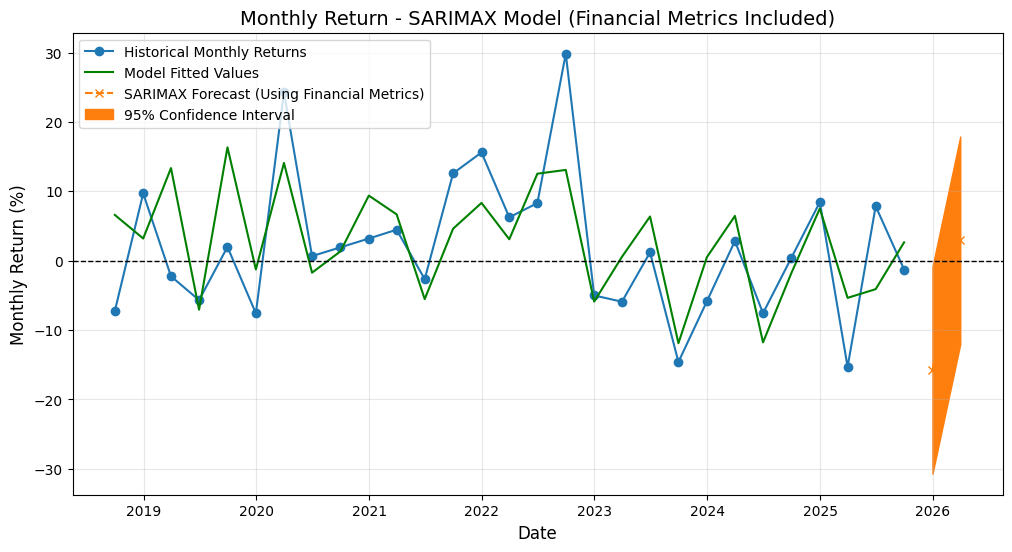

NFG
--- Forecasting 0.5 Years Ahead ---


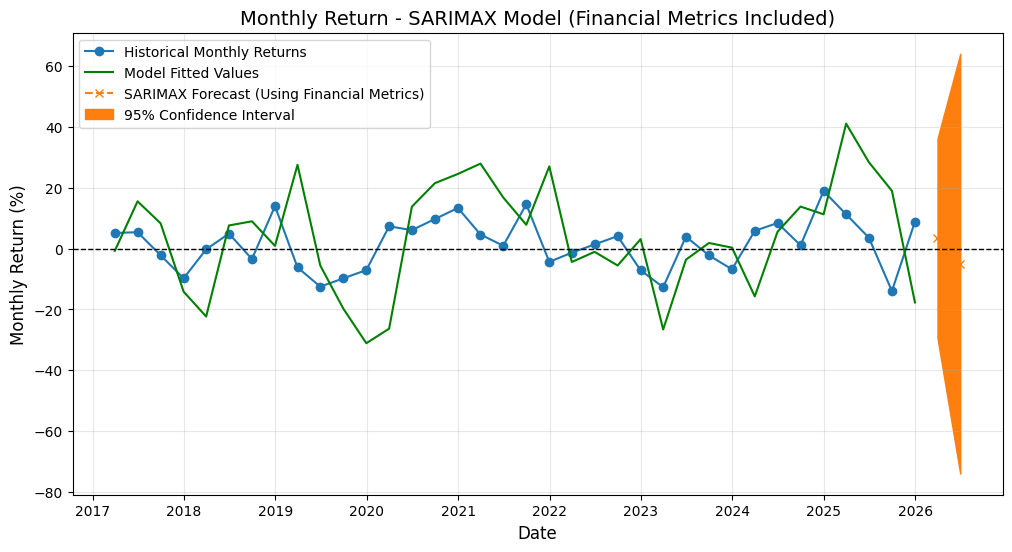

DVN
--- Forecasting 0.5 Years Ahead ---


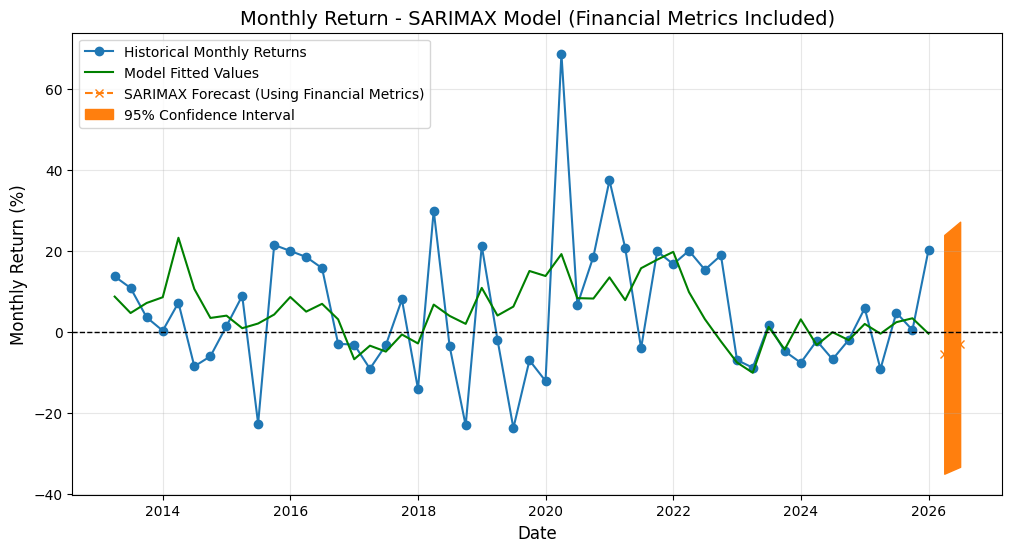

EXE
--- Forecasting 0.5 Years Ahead ---


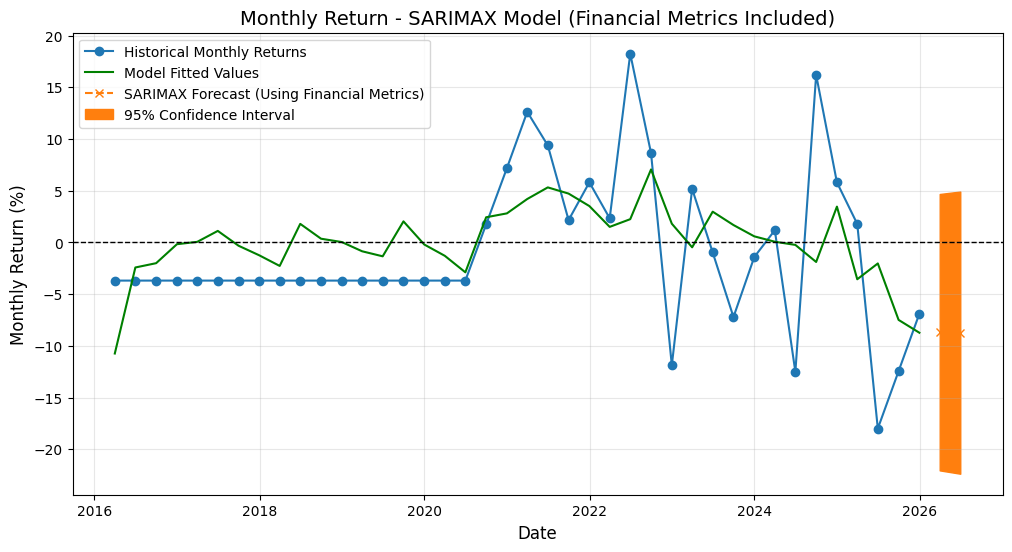

MTDR
--- Forecasting 0.5 Years Ahead ---


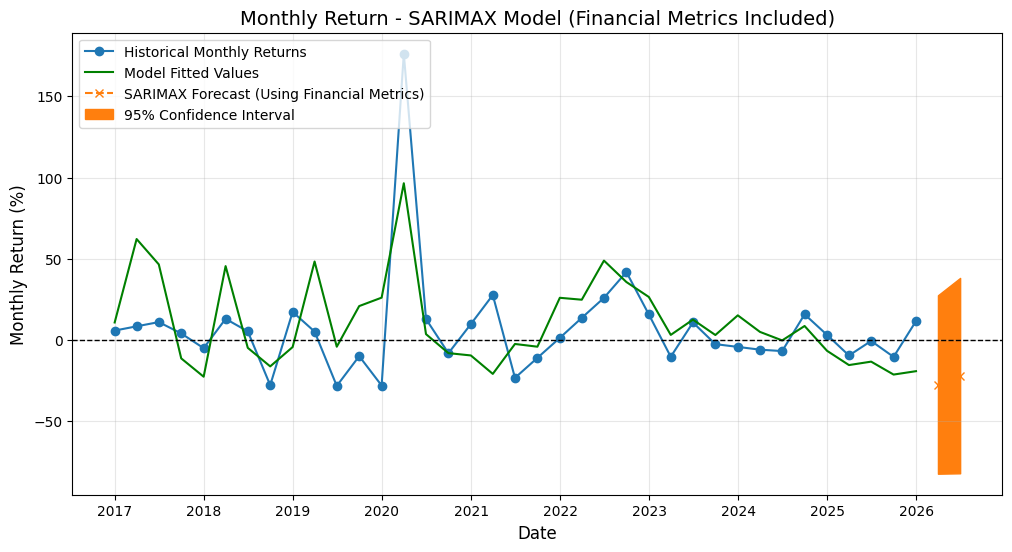

CNX
--- Forecasting 0.5 Years Ahead ---


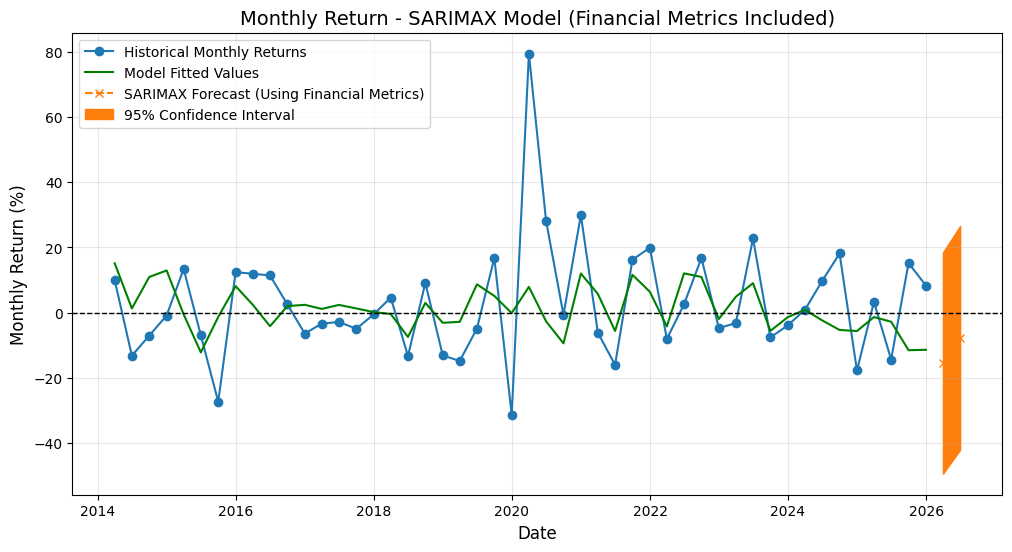

NOG
--- Forecasting 0.5 Years Ahead ---


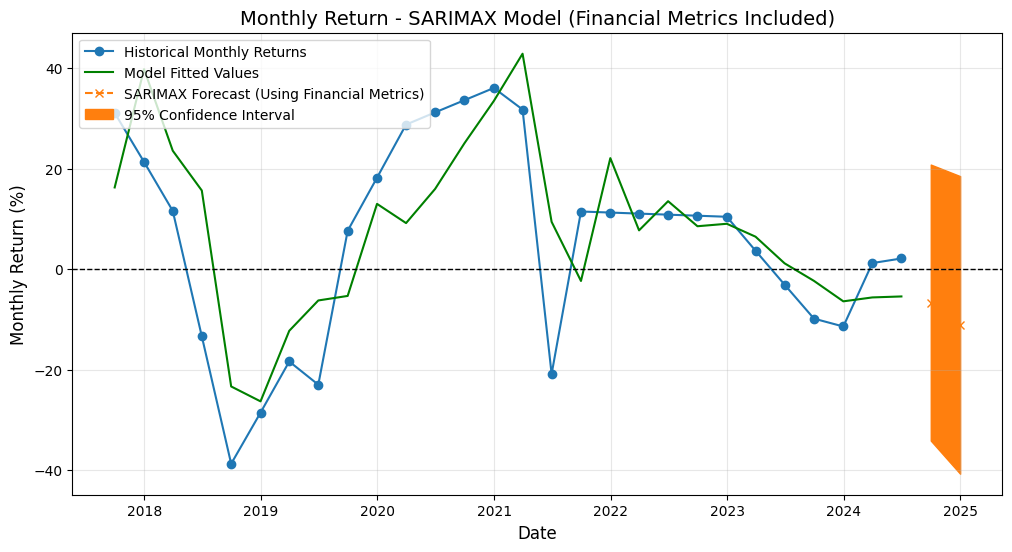

RRC
--- Forecasting 0.5 Years Ahead ---


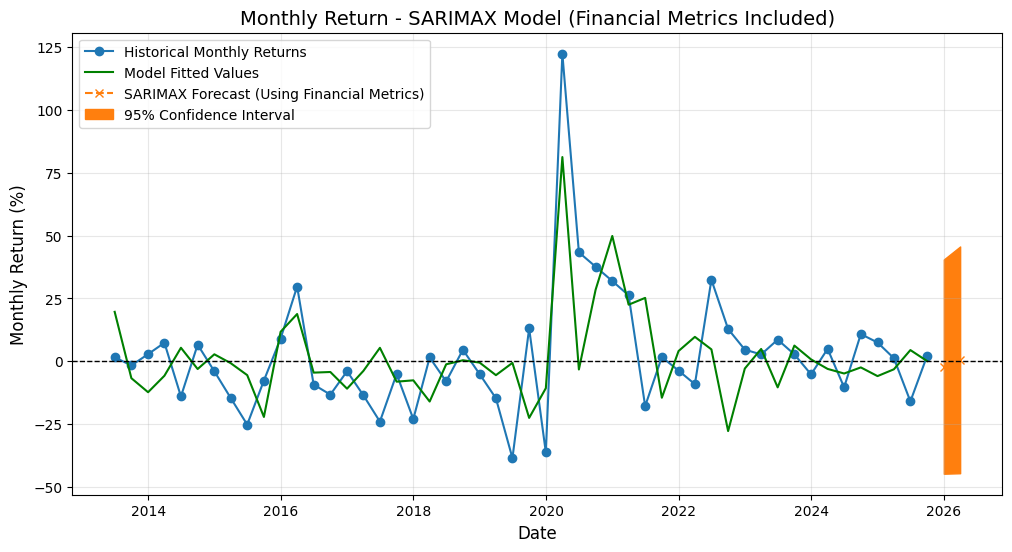

TALO
--- Forecasting 0.5 Years Ahead ---


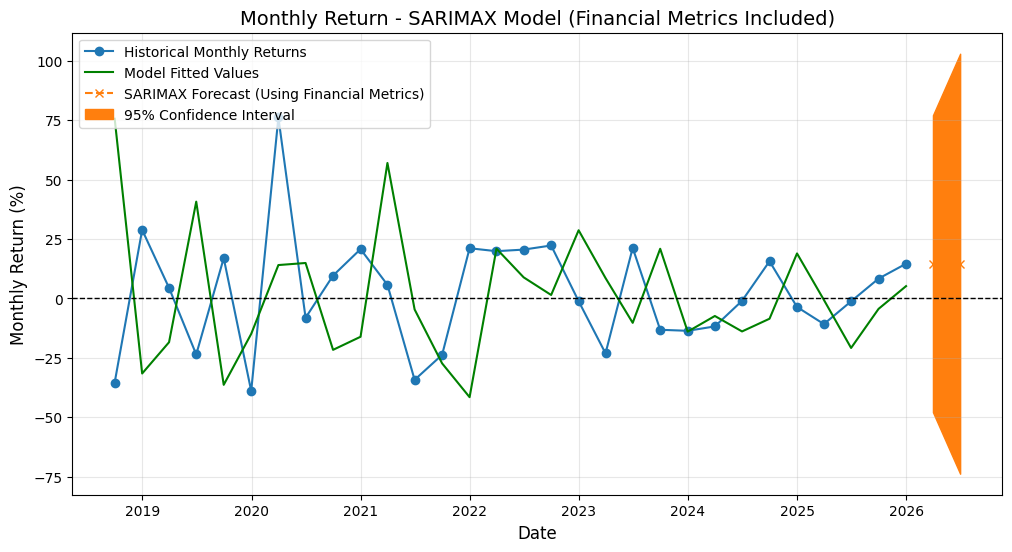

In [38]:
cumulative_returns = {}
all_stocks = stationary + unit_root

last_financials_vals = {
    **last_known_stationary,
    **last_known_unit_root
}

y_aligned_vals = {
    **y_aligned_stationary,
    **y_aligned_unit_root
}

sarimax_models = {
    **sarimax_model_stationary,
    **sarimax_model_unit_root
}

for stock_ticker in all_stocks:
    try:
        print(stock_ticker)
        y_aligned = y_aligned_vals[stock_ticker] 
        sarimax_model = sarimax_models[stock_ticker]
        last_known = last_financials_vals[stock_ticker]
        cumulative_returns[stock_ticker] = SARIMAX_Stock_Analysis(2, last_known, y_aligned, sarimax_model)
    except Exception as e:
        print(e)

Compute Stock Ranking

In [39]:
cumulative_returns

{'CVX': np.float64(-13.317900539306859),
 'NFG': np.float64(-1.7115997597514587),
 'DVN': np.float64(-8.448644203119926),
 'EXE': np.float64(-16.644082691264263),
 'MTDR': np.float64(-43.267520339515585),
 'CNX': np.float64(-21.904677208513935),
 'NOG': np.float64(-16.962088046189162),
 'RRC': np.float64(-1.5641982834019186),
 'TALO': np.float64(31.35405486009639)}

In [40]:
df_returns = pd.DataFrame(list(cumulative_returns.items()), columns=["Ticker", "Cumulative Return (%)"])
df_sorted = df_returns.sort_values(by="Cumulative Return (%)", ascending=False).reset_index(drop=True)
df_sorted

,Ticker,Cumulative Return (%)
0,TALO,31.354055
1,RRC,-1.564198
2,NFG,-1.711600
3,DVN,-8.448644
4,CVX,-13.317901
5,EXE,-16.644083
6,NOG,-16.962088
7,CNX,-21.904677
8,MTDR,-43.267520
